In [ ]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import pandas as pd

def resolve_code_root() -> Path:
    cwd = Path.cwd().resolve()
    base = cwd.parent if cwd.name == 'notebooks' else cwd
    if (base / 'utils').exists():
        return base
    if (base / 'phase_3_5_starter' / 'utils').exists():
        return base / 'phase_3_5_starter'
    if (Path('/mnt/data/phase_3_5_starter') / 'utils').exists():
        return Path('/mnt/data/phase_3_5_starter')
    return base

CODE_ROOT = resolve_code_root()
DATA_ROOT = CODE_ROOT
if not ((DATA_ROOT / 'data' / 'score' / 'evaluation_pairs_multiclass.csv').exists() or (DATA_ROOT / 'evaluation_pairs_multiclass.csv').exists()):
    DATA_ROOT = CODE_ROOT.parent

sys.path.append(str(CODE_ROOT))

from utils.feature_engineering import FEATURE_COLUMNS
from utils.eval_helpers import (
    get_feature_importance_dataframe,
    plot_confusion_matrix,
    plot_feature_importance,
    plot_model_comparison,
    plot_multiclass_roc,
)

DATA_DIR = DATA_ROOT if ((DATA_ROOT / 'clean_resume.csv').exists() or (DATA_ROOT / 'clean_job.csv').exists() or (DATA_ROOT / 'job_descriptions.csv').exists() or (DATA_ROOT / 'evaluation_pairs_multiclass.csv').exists()) else (DATA_ROOT / 'data')
SCORE_DIR = DATA_DIR / 'score'
REPORT_METRICS_DIR = CODE_ROOT / 'reports' / 'metrics'
PLOT_DIR = CODE_ROOT / 'reports' / 'plots'
MODEL_SAVE_DIR = CODE_ROOT / 'models' / 'saved'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

print('CODE_ROOT =', CODE_ROOT)
print('DATA_ROOT =', DATA_ROOT)

CODE_ROOT = D:\myproject
DATA_ROOT = D:\myproject


In [ ]:
results_df = pd.read_csv(REPORT_METRICS_DIR / 'model_results.csv')
pred_df = pd.read_csv(REPORT_METRICS_DIR / 'best_model_test_predictions.csv')
dataset_df = pd.read_csv(SCORE_DIR / 'evaluation_pairs_multiclass.csv')
bundle = joblib.load(MODEL_SAVE_DIR / 'best_model_bundle.joblib')

print(results_df)
print('Best model from bundle:', bundle['model_name'])

                model_name model_family  fit_seconds  predict_seconds  \
0            Random Forest      Bagging        2.034            0.183   
1  Bagging (Decision Tree)      Bagging       10.340            0.215   
2        Gradient Boosting     Boosting        5.581            0.021   
3        Stacking Ensemble     Stacking       27.277            0.167   
4                SVM (RBF)       Kernel       11.378            1.967   
5      Logistic Regression       Linear        0.108            0.004   
6                 AdaBoost     Boosting        3.143            0.157   

   accuracy  precision_macro  recall_macro  f1_macro  precision_weighted  \
0  0.809447         0.812538      0.806814  0.808385            0.814822   
1  0.801396         0.801450      0.798595  0.799471            0.803610   
2  0.800859         0.802400      0.797916  0.799138            0.804745   
3  0.803543         0.799668      0.799820  0.799059            0.801664   
4  0.789587         0.796243      0

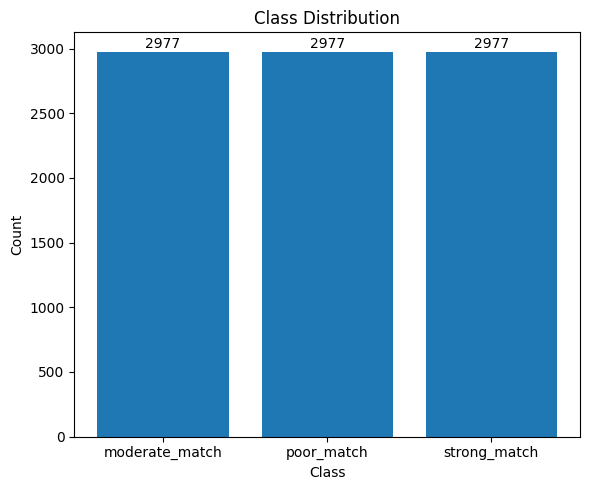

In [ ]:
# 1) Class distribution
fig, ax = plt.subplots(figsize=(6, 5))
class_counts = dataset_df['label_name'].value_counts().sort_index()
ax.bar(class_counts.index, class_counts.values)
ax.set_title('Class Distribution')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
for i, val in enumerate(class_counts.values):
    ax.text(i, val + max(class_counts.values) * 0.001, str(val), ha='center', va='bottom')
plt.tight_layout()
fig.savefig(PLOT_DIR / 'class_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

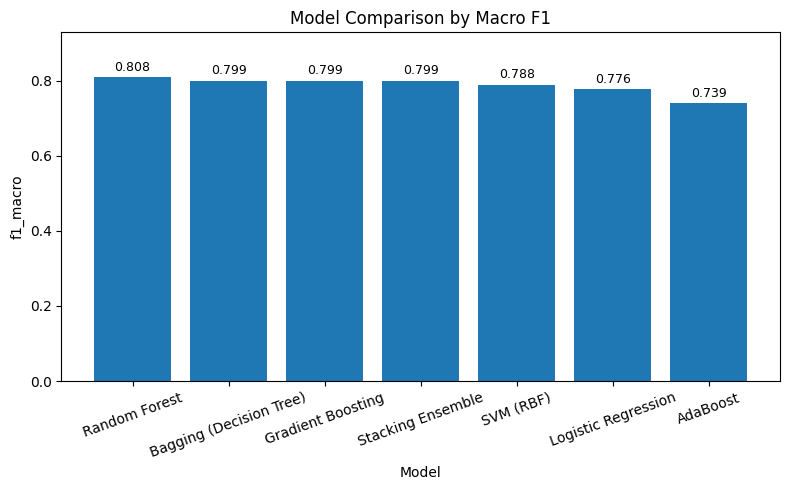

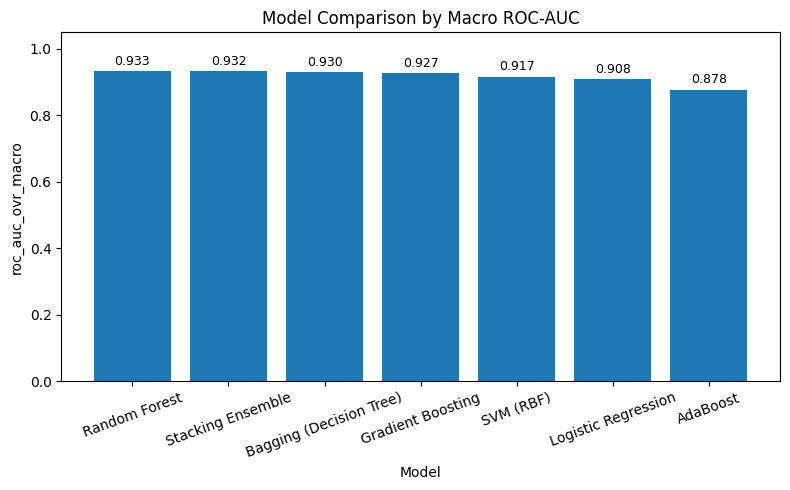

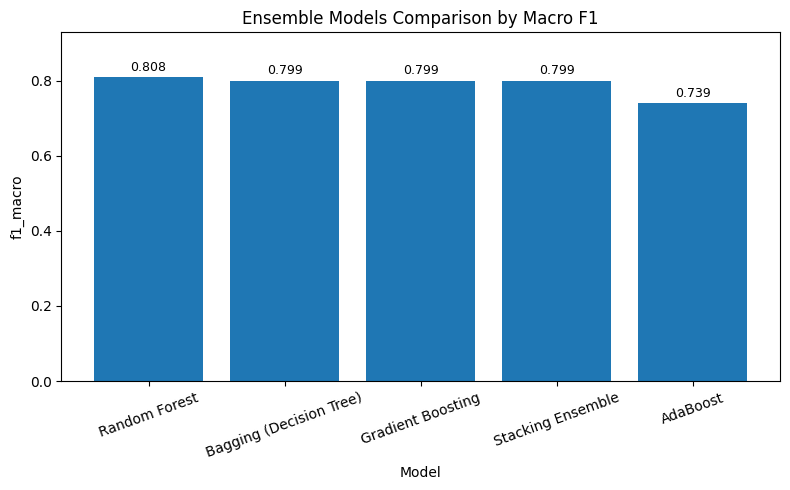

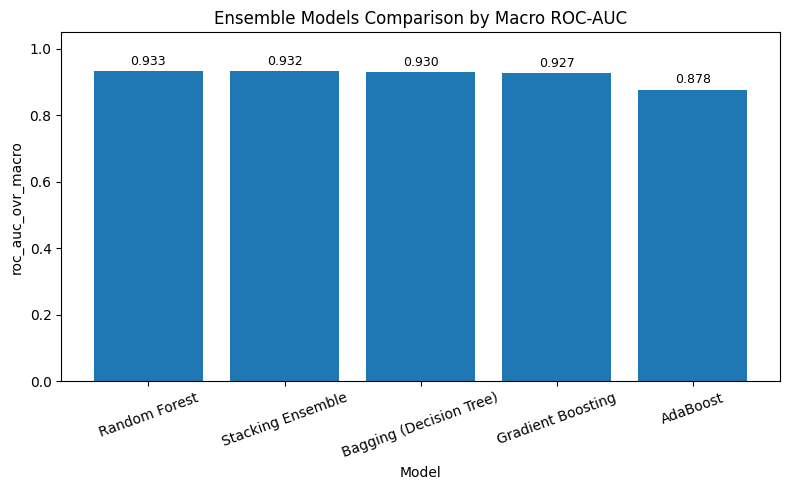

In [4]:
# 2) Model comparison plots
plot_model_comparison(
    results_df,
    metric_col='f1_macro',
    title='Model Comparison by Macro F1',
    save_path=PLOT_DIR / 'model_comparison_macro_f1.png',
)
plt.show()

plot_model_comparison(
    results_df,
    metric_col='roc_auc_ovr_macro',
    title='Model Comparison by Macro ROC-AUC',
    save_path=PLOT_DIR / 'model_comparison_roc_auc.png',
)
plt.show()

# Ensemble-only comparison (Bagging / Boosting / Stacking families)
if 'model_family' in results_df.columns:
    ensemble_df = results_df[results_df['model_family'].isin(['Bagging', 'Boosting', 'Stacking'])].copy()
else:
    ensemble_names = ['Random Forest', 'Gradient Boosting', 'Bagging (Decision Tree)', 'AdaBoost', 'Stacking Ensemble']
    ensemble_df = results_df[results_df['model_name'].isin(ensemble_names)].copy()

if not ensemble_df.empty:
    plot_model_comparison(
        ensemble_df,
        metric_col='f1_macro',
        title='Ensemble Models Comparison by Macro F1',
        save_path=PLOT_DIR / 'ensemble_comparison_macro_f1.png',
    )
    plt.show()

    plot_model_comparison(
        ensemble_df,
        metric_col='roc_auc_ovr_macro',
        title='Ensemble Models Comparison by Macro ROC-AUC',
        save_path=PLOT_DIR / 'ensemble_comparison_roc_auc.png',
    )
    plt.show()
else:
    print('No ensemble models found in results_df.')

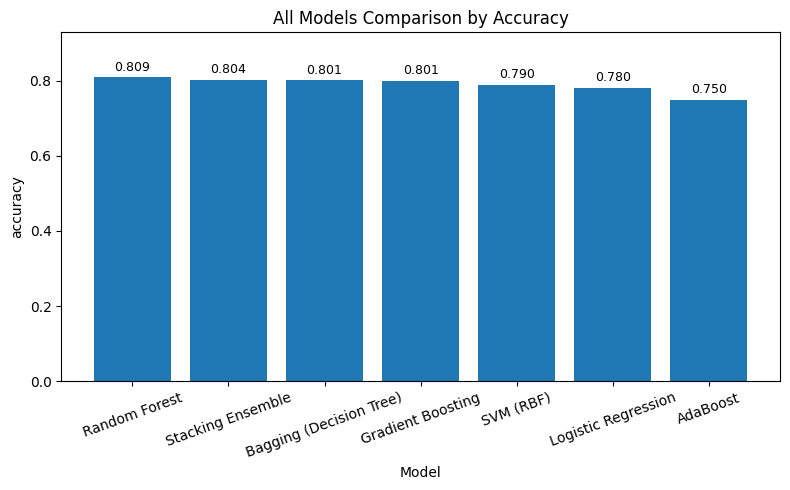

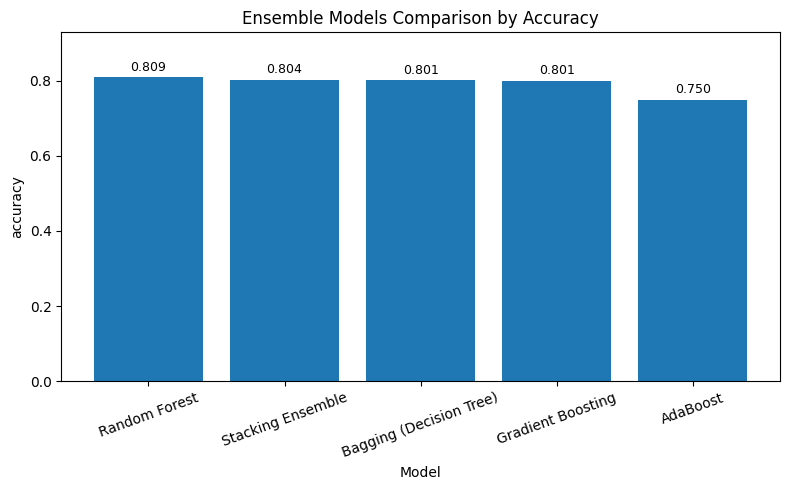

In [5]:
# Model comparison by accuracy
plot_model_comparison(
    results_df,
    metric_col='accuracy',
    title='All Models Comparison by Accuracy',
    save_path=PLOT_DIR / 'all_models_comparison_accuracy.png',
)
plt.show()

# Ensemble-only comparison by accuracy
if not ensemble_df.empty:
    plot_model_comparison(
        ensemble_df,
        metric_col='accuracy',
        title='Ensemble Models Comparison by Accuracy',
        save_path=PLOT_DIR / 'ensemble_comparison_accuracy.png',
    )
    plt.show()
else:
    print('No ensemble models found in results_df.')

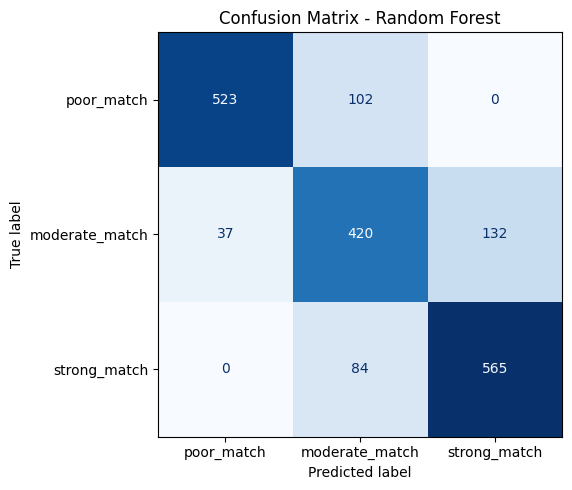

In [ ]:
# 3) Confusion matrix for best model
plot_confusion_matrix(
    y_true=pred_df['label'],
    y_pred=pred_df['pred_label'],
    title=f"Confusion Matrix - {bundle['model_name']}",
    save_path=PLOT_DIR / 'confusion_matrix_best_model.png',
)
plt.show()

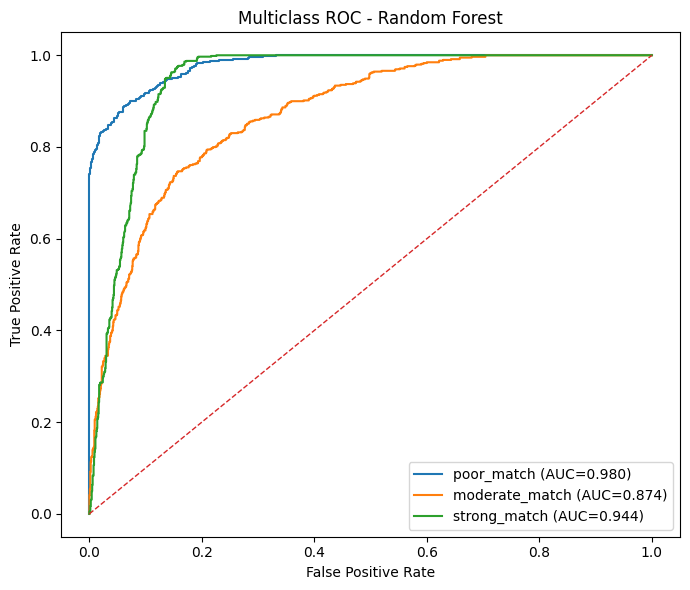

In [ ]:
# 4) Multiclass ROC curve for best model
plot_multiclass_roc(
    y_true=pred_df['label'],
    y_prob=pred_df[['proba_0', 'proba_1', 'proba_2']].values,
    title=f"Multiclass ROC - {bundle['model_name']}",
    save_path=PLOT_DIR / 'multiclass_roc_best_model.png',
)
plt.show()

In [8]:
# 5) Feature importance
feature_cols = bundle['feature_columns']
model = bundle['model']
X = dataset_df[feature_cols]
y = dataset_df['label']

# Stacking / other meta-models may require permutation importance.
# To keep runtime manageable, use a sample for large datasets when the model
# does not expose direct feature importances / coefficients.
X_imp = X
y_imp = y
uses_permutation = not (hasattr(model, 'feature_importances_') or hasattr(model, 'coef_'))

if uses_permutation and len(X) > 3000:
    sample_idx = dataset_df.sample(n=3000, random_state=42).index
    X_imp = X.loc[sample_idx].reset_index(drop=True)
    y_imp = y.loc[sample_idx].reset_index(drop=True)
    print(f'Using sampled permutation importance on {len(X_imp)} rows for {bundle["model_name"]}.')
else:
    print(f'Using full dataset importance on {len(X_imp)} rows for {bundle["model_name"]}.')

importance_df = get_feature_importance_dataframe(model, X_imp, y_imp, feature_cols)
importance_df.head(15)

Using full dataset importance on 8931 rows for Random Forest.


,feature,importance
0,embedding_similarity,0.300184
1,tfidf_similarity,0.170157
2,keyword_overlap,0.117420
3,experience_match_score,0.065144
4,domain_match_score,0.051795
5,job_min_years,0.043126
6,length_balance_score,0.042954
7,resume_years_detected,0.031674
8,job_length_score,0.030730
9,required_skill_coverage,0.025036


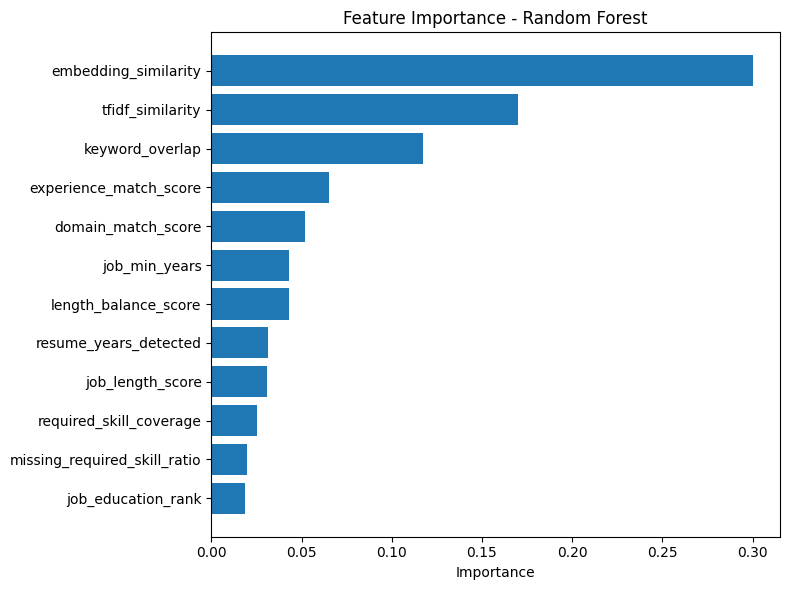

In [ ]:
plot_feature_importance(
    importance_df,
    top_n=12,
    title=f"Feature Importance - {bundle['model_name']}",
    save_path=PLOT_DIR / 'feature_importance_best_model.png',
)
plt.show()